<a href="https://colab.research.google.com/github/bhanuprakash227/DataScience_ExcelR_Assignments/blob/main/14_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PCA**

**Data Preparation**

In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

df = pd.read_csv("wine.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nSummary Statistics:")
print(df.describe())

Dataset Shape: (178, 14)

First 5 Rows:
   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2.29   5.64  1.04      3.92     1065  
1           0.26             1.28   4.38  1.05      3.40     1050  
2           0.30             2.81   5.68  1.03      3.17     1185  
3           0.24             2.18   7.80  0.86      3.45     1480  
4           0.39             1.82   4.32  1.04      2.93      735  

Data Types:
Type                 int64
Alcohol            float64
Malic              flo

**Exploratory Data Analysis**

In [13]:

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nUnique Values:")
print(df.nunique())

print("\nTarget/Class Distribution:")
print(df["Type"].value_counts())

Missing Values:
Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

Duplicate Rows: 0

Unique Values:
Type                 3
Alcohol            126
Malic              133
Ash                 79
Alcalinity          63
Magnesium           53
Phenols             97
Flavanoids         132
Nonflavanoids       39
Proanthocyanins    101
Color              132
Hue                 78
Dilution           122
Proline            121
dtype: int64

Target/Class Distribution:
Type
2    71
1    59
3    48
Name: count, dtype: int64


**Data Visualization**

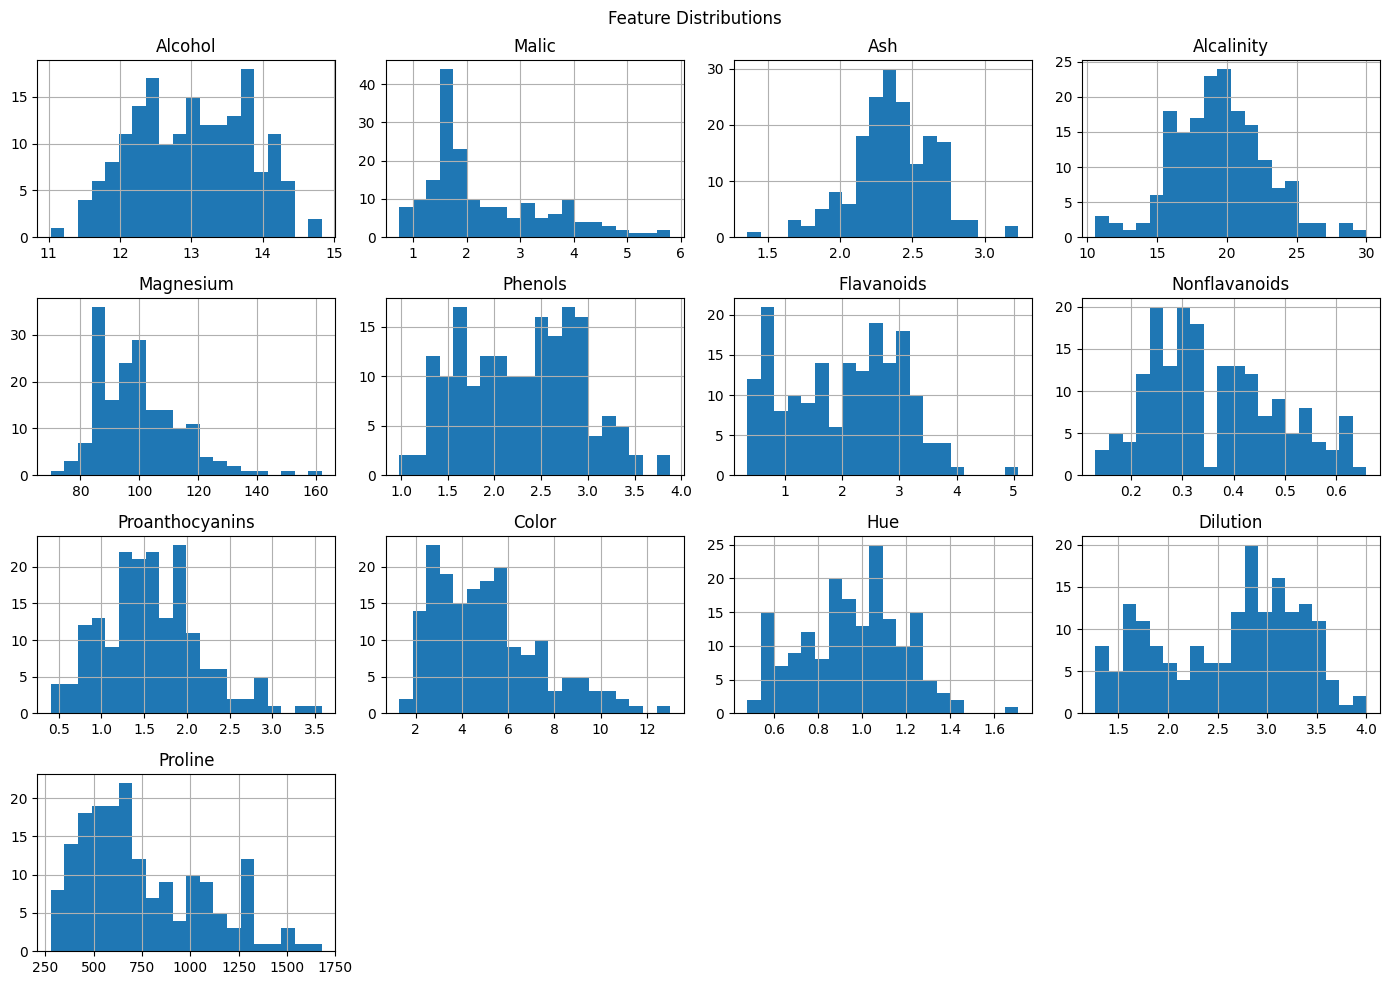

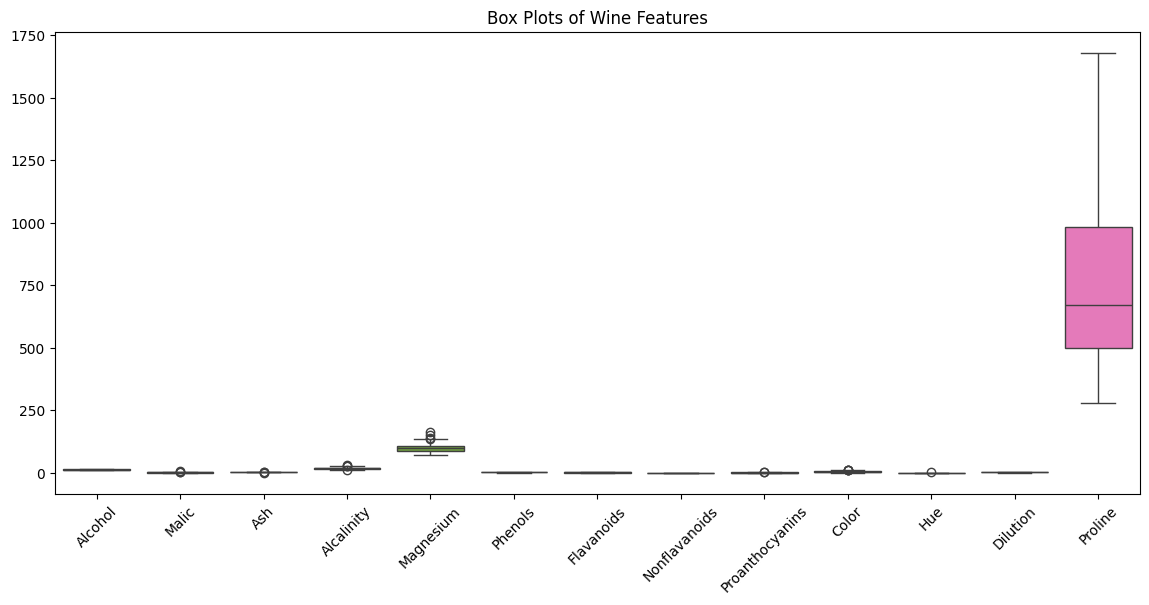

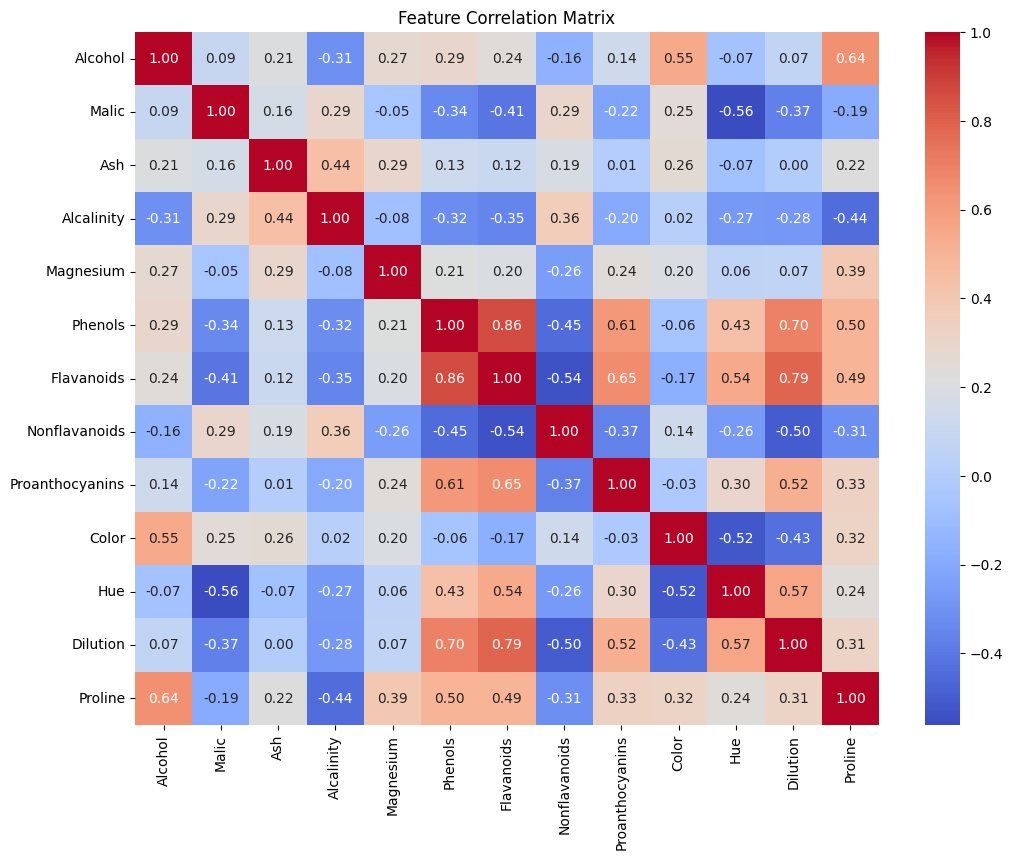

In [14]:

features = df.drop(columns=["Type"])

features.hist(figsize=(14, 10), bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(data=features)
plt.title("Box Plots of Wine Features")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 9))
sns.heatmap(features.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

**Feature Standardization**

In [15]:

X = df.drop(columns=["Type"]).copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original Feature Shape:", X.shape)
print("Standardized Feature Shape:", X_scaled.shape)
print("\nFeature Means After Standardization:")
print(np.round(X_scaled.mean(axis=0), 6))
print("\nFeature Standard Deviations After Standardization:")
print(np.round(X_scaled.std(axis=0), 6))

Original Feature Shape: (178, 13)
Standardized Feature Shape: (178, 13)

Feature Means After Standardization:
[-0. -0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]

Feature Standard Deviations After Standardization:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Principal Component Analysis**

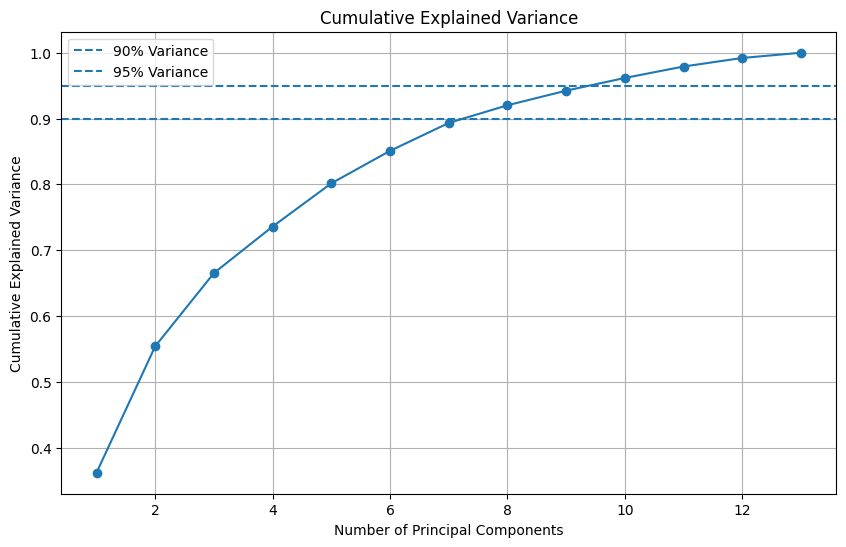

Explained Variance Ratio:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]

Cumulative Explained Variance:
[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]

Optimal Number of Components for 90% Variance: 8


In [16]:

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.90, linestyle="--", label="90% Variance")
plt.axhline(y=0.95, linestyle="--", label="95% Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid()
plt.show()

optimal_components = np.argmax(cumulative_variance >= 0.90) + 1

print("Explained Variance Ratio:")
print(explained_variance)

print("\nCumulative Explained Variance:")
print(cumulative_variance)

print("\nOptimal Number of Components for 90% Variance:", optimal_components)

**PCA Transformation**

In [17]:

pca = PCA(n_components=optimal_components)
X_pca = pca.fit_transform(X_scaled)

pca_columns = [f"PC{i+1}" for i in range(optimal_components)]
pca_df = pd.DataFrame(X_pca, columns=pca_columns)

print("PCA Data Shape:", pca_df.shape)
print("\nPCA Data:")
print(pca_df.head())

print("\nExplained Variance by Selected Components:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:",
      pca.explained_variance_ratio_.sum())

PCA Data Shape: (178, 8)

PCA Data:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  3.316751  1.443463 -0.165739 -0.215631  0.693043  0.223880  0.596427   
1  2.209465 -0.333393 -2.026457 -0.291358 -0.257655  0.927120  0.053776   
2  2.516740  1.031151  0.982819  0.724902 -0.251033 -0.549276  0.424205   
3  3.757066  2.756372 -0.176192  0.567983 -0.311842 -0.114431 -0.383337   
4  1.008908  0.869831  2.026688 -0.409766  0.298458  0.406520  0.444074   

        PC8  
0 -0.065139  
1 -1.024416  
2  0.344216  
3 -0.643593  
4 -0.416700  

Explained Variance by Selected Components:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749]

Total Explained Variance: 0.9201754434577263


**Clustering on Original Data**

In [18]:

k_values = range(2, 9)
silhouette_scores_original = []
db_scores_original = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores_original.append(silhouette_score(X_scaled, labels))
    db_scores_original.append(davies_bouldin_score(X_scaled, labels))

best_k_original = k_values[np.argmax(silhouette_scores_original)]

kmeans_original = KMeans(
    n_clusters=best_k_original,
    random_state=42,
    n_init=10
)

original_labels = kmeans_original.fit_predict(X_scaled)

print("Best K for Original Data:", best_k_original)
print("Silhouette Score:",
      silhouette_score(X_scaled, original_labels))
print("Davies-Bouldin Index:",
      davies_bouldin_score(X_scaled, original_labels))

Best K for Original Data: 3
Silhouette Score: 0.2848589191898987
Davies-Bouldin Index: 1.3891879777181648


**Original Data Clustering Visualization**

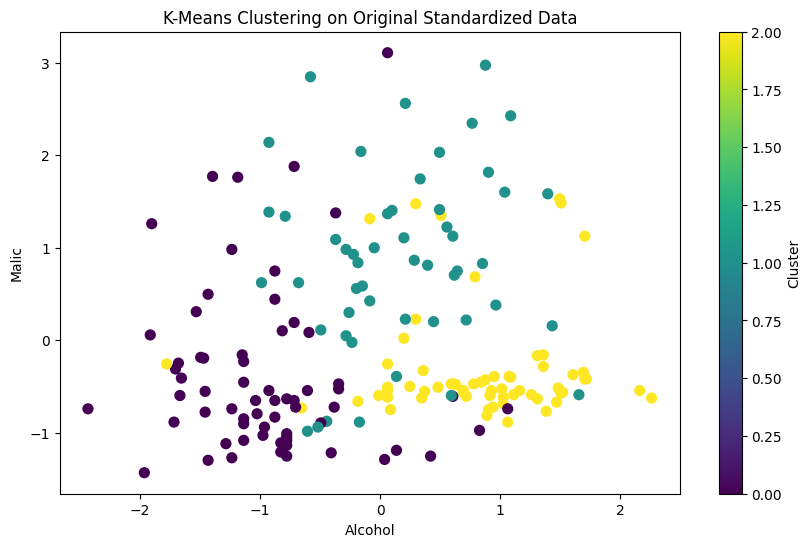

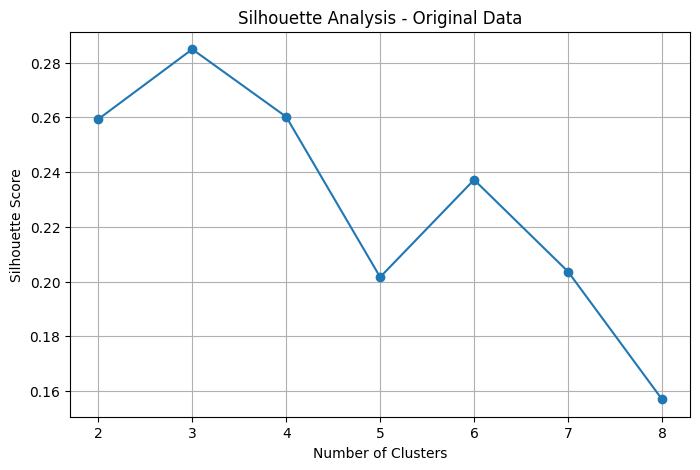

In [19]:

plt.figure(figsize=(10, 6))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=original_labels,
    cmap="viridis",
    s=50
)
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("K-Means Clustering on Original Standardized Data")
plt.colorbar(label="Cluster")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores_original, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis - Original Data")
plt.grid()
plt.show()

**Clustering on PCA Data**

In [20]:

silhouette_scores_pca = []
db_scores_pca = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    silhouette_scores_pca.append(silhouette_score(X_pca, labels))
    db_scores_pca.append(davies_bouldin_score(X_pca, labels))

best_k_pca = k_values[np.argmax(silhouette_scores_pca)]

kmeans_pca = KMeans(
    n_clusters=best_k_pca,
    random_state=42,
    n_init=10
)

pca_labels = kmeans_pca.fit_predict(X_pca)

print("Best K for PCA Data:", best_k_pca)
print("Silhouette Score:",
      silhouette_score(X_pca, pca_labels))
print("Davies-Bouldin Index:",
      davies_bouldin_score(X_pca, pca_labels))

Best K for PCA Data: 3
Silhouette Score: 0.3149696954705561
Davies-Bouldin Index: 1.2668818314972183


**PCA Clustering Visualization**

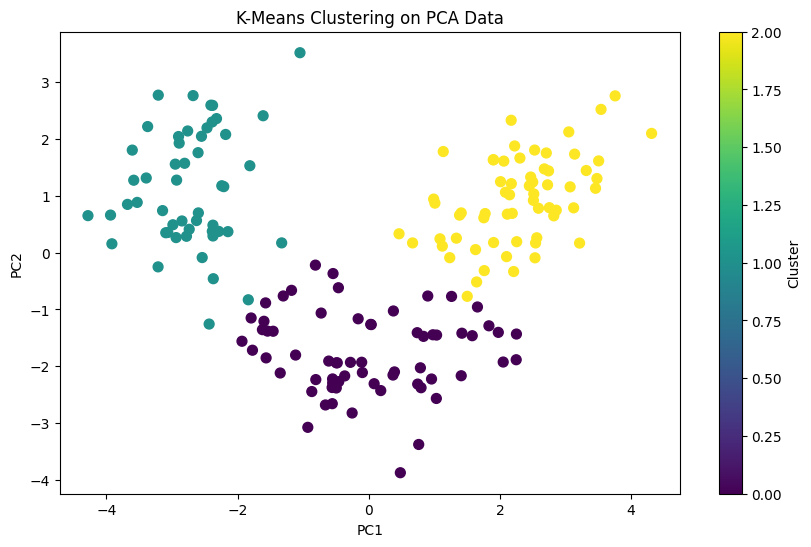

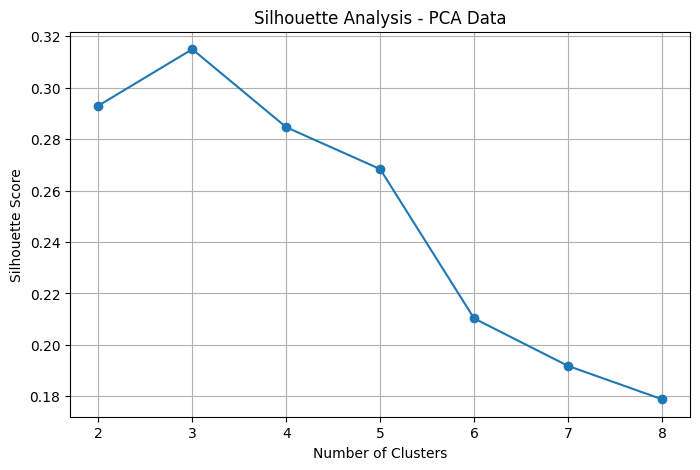

In [21]:

plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=pca_labels,
    cmap="viridis",
    s=50
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering on PCA Data")
plt.colorbar(label="Cluster")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores_pca, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis - PCA Data")
plt.grid()
plt.show()

**Clustering Comparison**

                      Dataset  Number of Components  Number of Clusters  \
0  Original Standardized Data                    13                   3   
1                    PCA Data                     8                   3   

   Silhouette Score  Davies-Bouldin Index  
0          0.284859              1.389188  
1          0.314970              1.266882  


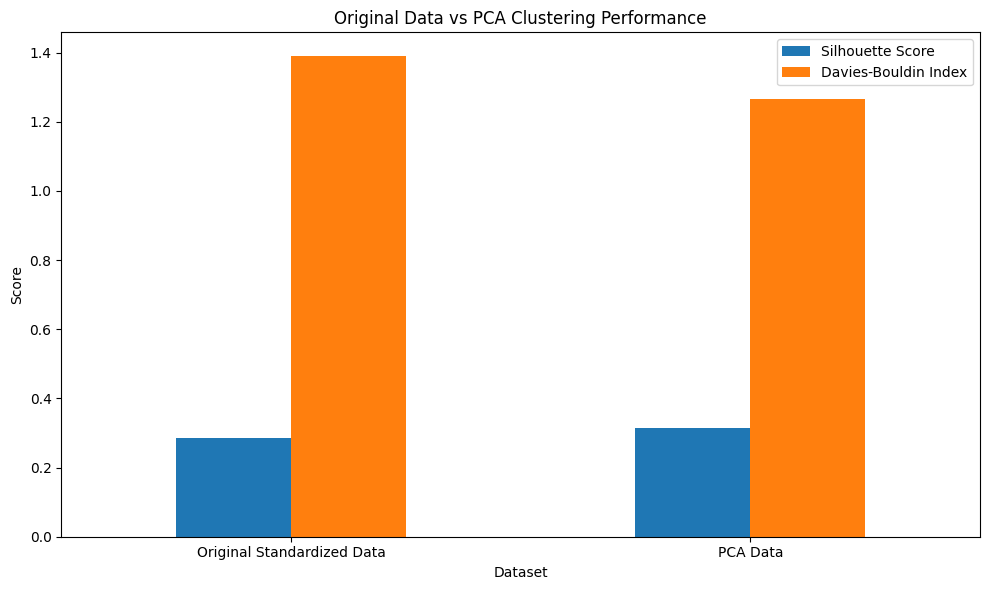

In [22]:

original_silhouette = silhouette_score(X_scaled, original_labels)
original_db = davies_bouldin_score(X_scaled, original_labels)

pca_silhouette = silhouette_score(X_pca, pca_labels)
pca_db = davies_bouldin_score(X_pca, pca_labels)

comparison = pd.DataFrame({
    "Dataset": ["Original Standardized Data", "PCA Data"],
    "Number of Components": [X_scaled.shape[1], X_pca.shape[1]],
    "Number of Clusters": [best_k_original, best_k_pca],
    "Silhouette Score": [original_silhouette, pca_silhouette],
    "Davies-Bouldin Index": [original_db, pca_db]
})

print(comparison)

comparison.set_index("Dataset")[["Silhouette Score", "Davies-Bouldin Index"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Original Data vs PCA Clustering Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##**Comparison and Analysis**
* Clustering on the original standardized dataset uses all available features, while PCA clustering uses a smaller number of principal components containing most of the important variance.

* A higher **Silhouette Score** indicates better-separated and more cohesive clusters. A lower **Davies-Bouldin Index** indicates better clustering performance.

* PCA can reduce dimensionality, remove redundant information, reduce computational complexity, and make visualization easier. However, PCA transforms the original features into principal components, which can make the resulting clusters less directly interpretable.

* The final comparison should be based on the actual Silhouette Score and Davies-Bouldin Index produced by the cells.

##**Trade-offs Between PCA and Direct Clustering**
**Original Data:**
- Preserves all original features.
- Easier to relate clusters to the original variables.
- May contain redundant or highly correlated information.
- Can become less efficient with high-dimensional data.

**PCA + Clustering:**
- Reduces the number of dimensions.
- Can improve computational efficiency.
- Helps visualize high-dimensional data.
- May remove some information.
- Principal components are less directly interpretable than original features.

##**Conclusion and Practical Implications**
* PCA is useful when a dataset contains many correlated or redundant features and dimensionality needs to be reduced. K-Means clustering can then be applied to the reduced representation to identify groups of similar observations.

* For this Wine dataset, the best approach should be selected by comparing the Silhouette Score and Davies-Bouldin Index obtained from the original and PCA-transformed data.

**Recommendation:** Use clustering on the original standardized data when interpretability of the original features is important. Use PCA before clustering when dimensionality reduction, visualization, or computational efficiency is important. This directly addresses the assignment's requested comparison, trade-offs, and recommendations.